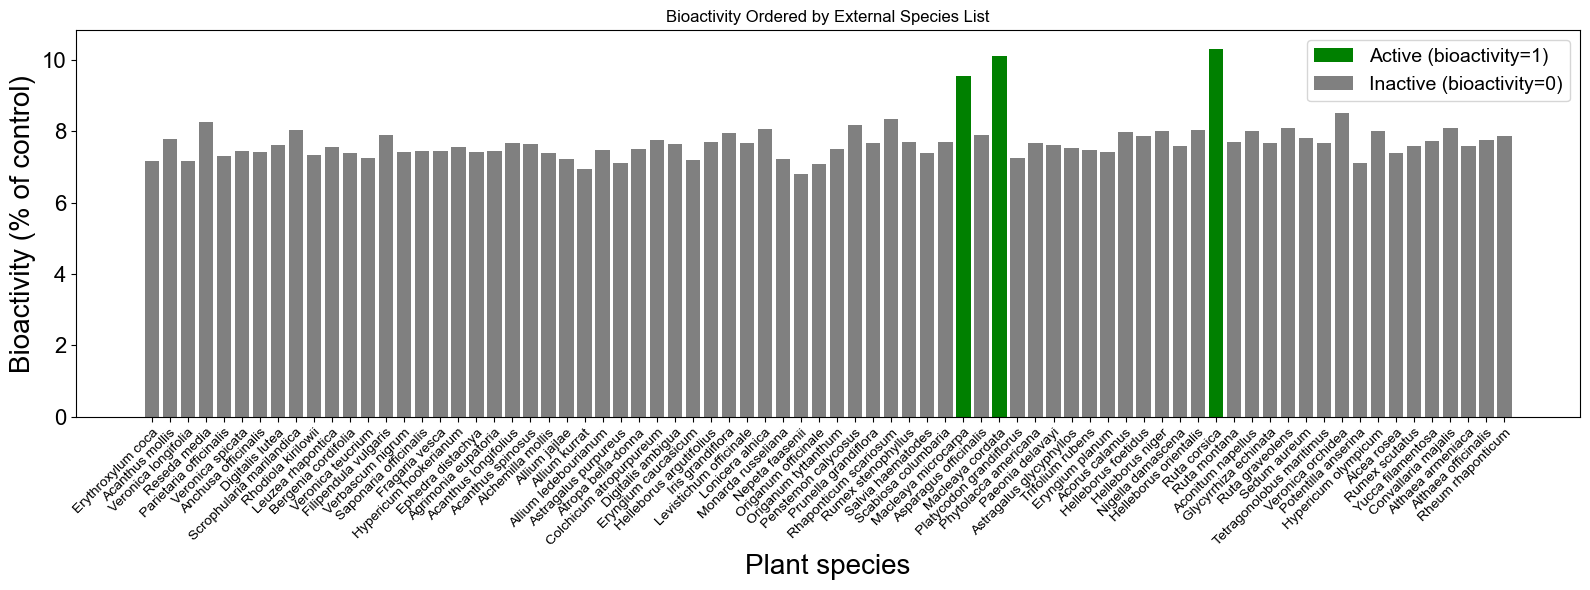

,Species,Sample real number,Sample ID,fluorescence_plate1,fluorescence_plate2,bioactivity,avg_fluo,Species_clean,sort_order,rel_bioactivity
0,Erythroxylum coca,1,0.0,52119,37977,0,45048.0,Erythroxylum coca,1,7.181229
1,Acanthus mollis,2,1.1,44885,38110,0,41497.5,Acanthus mollis,2,7.795650
2,Veronica longifolia,3,2.1,45617,44611,0,45114.0,Veronica longifolia,3,7.170723
3,Reseda media,4,3.1,41435,36780,0,39107.5,Reseda media,4,8.272071
4,Parietaria officinalis,5,4.1,46336,42291,0,44313.5,Parietaria officinalis,5,7.300258
...,...,...,...,...,...,...,...,...,...,...
71,Yucca filamentosa,53,74.1,42281,41578,0,41929.5,Yucca filamentosa,139,7.715332
72,Convallaria majalis,54,77.1,39487,40389,0,39938.0,Convallaria majalis,140,8.100055
73,Althaea armeniaca,55,79.1,42836,42326,0,42581.0,Althaea armeniaca,141,7.597285
74,Althaea officinalis,56,80.1,41868,41456,0,41662.0,Althaea officinalis,142,7.764870


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl
from pathlib import Path

# Set global font and SVG text export settings
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['svg.fonttype'] = 'none'

project_root = Path.cwd()

fluorescence_graph_file = project_root / "data" / "plant_extract_fluorescence_graph.xlsx"
species_file = project_root / "data" / "Table_Plant_Species.xlsx"

# Load data
df_graph = pd.read_excel(fluorescence_graph_file)
df_species = pd.read_excel(species_file)

# Compute average fluorescence
df_graph["avg_fluo"] = (df_graph["fluorescence_plate1"] + df_graph["fluorescence_plate2"]) / 2

# Clean and match plant species
df_species["Plant_clean"] = df_species["Plant species"].str.strip()
df_graph["Species_clean"] = df_graph["Species"].str.strip()

# Keep only overlapping species
valid_species = df_species["Plant_clean"].dropna().unique()
df_filtered = df_graph[df_graph["Species_clean"].isin(valid_species)].copy()

# Add sort order based on the new species file
species_order = df_species.drop_duplicates("Plant_clean")["Plant_clean"].tolist()
df_filtered["sort_order"] = df_filtered["Species_clean"].apply(lambda x: species_order.index(x) if x in species_order else -1)
df_filtered = df_filtered[df_filtered["sort_order"] != -1].copy()

# Use control fluorescence from df_graph (bioactivity == 2)
control_fluo = df_graph.loc[df_graph["bioactivity"] == 2, "avg_fluo"].values[0]

# Compute relative bioactivity
df_filtered["rel_bioactivity"] = (control_fluo / df_filtered["avg_fluo"]) * 100

# Keep only samples with bioactivity 0 or 1
df_filtered = df_filtered[df_filtered["bioactivity"].isin([0, 1])].copy()

# Sort by species order from external file
df_filtered.sort_values(by="sort_order", inplace=True)

# Assign colors to bars
color_map = {0: "gray", 1: "green"}
colors = df_filtered["bioactivity"].map(color_map)

# Plot with species names as x-axis labels
plt.figure(figsize=(16, 6))
plt.bar(range(len(df_filtered)), df_filtered["rel_bioactivity"], color=colors)
plt.xlabel("Plant species", fontsize=20)
plt.ylabel("Bioactivity (% of control)", fontsize=20)
plt.xticks(
    ticks=range(len(df_filtered)),
    labels=df_filtered["Species_clean"],
    fontsize=8,
    font="Arial",
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)
plt.yticks(fontsize=16)
plt.title("Bioactivity Ordered by External Species List")
plt.ylim(0, df_filtered["rel_bioactivity"].max() * 1.05)
plt.legend(handles=[
    Patch(facecolor="green", label="Active (bioactivity=1)"),
    Patch(facecolor="gray", label="Inactive (bioactivity=0)")
], loc="upper right", fontsize=14)
plt.tight_layout()

# Save to SVG with editable text
plt.savefig("filtered_bioactivity_ordered1.svg", dpi=300, format="svg")
plt.show()

# Optional export
df_filtered.to_excel("filtered_bioactivity_ordered1.xlsx", index=False)
df = pd.read_excel("filtered_bioactivity_ordered1.xlsx")
df